In [13]:
%matplotlib inline
import torch
import torchvision  
import numpy as np
from torch.utils import data
from torchvision import transforms
from matplotlib_inline import backend_inline
import matplotlib.pyplot as plt

backend_inline.set_matplotlib_formats("svg")

In [14]:
trans = transforms.ToTensor() 
# 把一个取值范围是[0,255]的PIL.Image或者
# shape为(H,W,C)的numpy.ndarray，转换成
# 形状为[C,H,W]，取值范围是[0,1.0]的torch.FloadTensor

mnist_train = torchvision.datasets.FashionMNIST(root="../data", train=True, transform=trans, download=True)
mnist_test = torchvision.datasets.FashionMNIST(root="../data", train=False, transform=trans, download=True)

In [15]:
len(mnist_train), len(mnist_test)

(60000, 10000)

In [16]:
mnist_test[0][0].shape, mnist_test[0][0], mnist_train[0][1]

(torch.Size([1, 28, 28]),
 tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000

In [17]:
def get_fashion_mnist_labels(labels):
    """返回FashionMNIST数据集的文本标签"""
    text_labels = ['t-shirts', 'trouser', 'pullover',
                   'dress', 'coat', 'sandal', 'shirt',
                   'sneaker', 'bag', 'ankle boot']
    return [text_labels[i] for i in labels]

def return_names(labels: int):
    text_labels = ['t-shirts', 'trouser', 'pullover',
                   'dress', 'coat', 'sandal', 'shirt',
                   'sneaker', 'bag', 'ankle boot']
    return text_labels[labels]


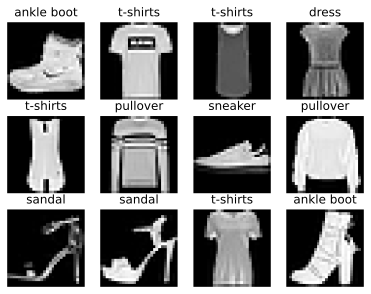

In [18]:
# 图像展示
fig, ax = plt.subplots(3, 4)
for i in range(12):
    ax[i // 4,i % 4].imshow(mnist_train[i][0].squeeze(), cmap='gray')
    ax[i // 4,i % 4].axis('off')
    ax[i // 4,i % 4].set_title(return_names(mnist_train[i][1]))
plt.show()


In [19]:
# 读取数据函数

batch_size = 256

def get_dataloader_workers():
    """使用12个进程来读取数据"""
    return 12

train_iter = data.DataLoader(mnist_train, batch_size, shuffle=True, num_workers=get_dataloader_workers())

from Timer import Timer

timer = Timer()

for X, y in train_iter:
    continue
print(f"{timer.stop():.6}s")

0.457146s


In [20]:
# 整合所有的组件, 获取FashionMNIST数据集，返回训练集和验证集的数据迭代器

def load_data_fashion_mnist(batch_size, resize=None):
    """下载FashionMNIST的数据集，然后将其加载到内存中"""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans) # 将多个transform组合起来
    mnist_train = torchvision.datasets.FashionMNIST(
        root="../data", train=True, transform=trans, download=True
    ) 
    mnist_test = torchvision.datasets.FashionMNIST(
        root="../data", train=False, transform=trans, download=True
    ) 

    return (data.DataLoader(mnist_train, batch_size, shuffle=True, 
                num_workers=get_dataloader_workers()),
            data.DataLoader(mnist_train, batch_size, shuffle=True,
                num_workers=get_dataloader_workers()))

In [21]:
train_iter, test_iter = load_data_fashion_mnist(32, resize=64)
for X, y in train_iter:
    print(X.shape, X.dtype, y.shape, y.dtype)

torch.Size([32, 1, 64, 64]) torch.float32 torch.Size([32]) torch.int64
torch.Size([32, 1, 64, 64]) torch.float32 torch.Size([32]) torch.int64
torch.Size([32, 1, 64, 64]) torch.float32 torch.Size([32]) torch.int64
torch.Size([32, 1, 64, 64]) torch.float32 torch.Size([32]) torch.int64
torch.Size([32, 1, 64, 64]) torch.float32 torch.Size([32]) torch.int64
torch.Size([32, 1, 64, 64]) torch.float32 torch.Size([32]) torch.int64
torch.Size([32, 1, 64, 64]) torch.float32 torch.Size([32]) torch.int64
torch.Size([32, 1, 64, 64]) torch.float32 torch.Size([32]) torch.int64
torch.Size([32, 1, 64, 64]) torch.float32 torch.Size([32]) torch.int64
torch.Size([32, 1, 64, 64]) torch.float32 torch.Size([32]) torch.int64
torch.Size([32, 1, 64, 64]) torch.float32 torch.Size([32]) torch.int64
torch.Size([32, 1, 64, 64]) torch.float32 torch.Size([32]) torch.int64
torch.Size([32, 1, 64, 64]) torch.float32 torch.Size([32]) torch.int64
torch.Size([32, 1, 64, 64]) torch.float32 torch.Size([32]) torch.int64
torch.